# 🟧 Sprint 3 – Optimización, Hiperparametrización y Modelo Final
### Proyecto: Predicción de Demanda Mensual – Olist

Objetivos del Sprint 3:
- Respetar la **temporalidad** del problema (split por `order_month`).
- Comparar modelos: **Naive, Regresión Lineal, RandomForest, XGBoost**.
- Aplicar **selección de features** (correlación + SelectKBest + feature importance).
- Realizar **hiperparametrización** de RandomForest (RandomizedSearchCV + TimeSeriesSplit).
- Evaluar con **backtest y test final**.
- Exportar el **modelo final `.pkl`** para uso mensual.


In [1]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

df   = pd.read_csv('/content/drive/MyDrive/TABLA_FINAL_MODULAR.csv',
                       parse_dates=['order_month']) # use parse_date porque como haremos un analisis temporal mensual y necesitamos
                                                                      # que no lo lea como objeto sino q respete datetime
                                                                      # para calcular tiempos de entrega, agrupar por mes y analizar la demanda por tiempo.
df.shape

Mounted at /content/drive


(1195, 175)

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

import joblib
from datetime import datetime

# Intentar importar XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("✅ XGBoost disponible.")
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️ XGBoost NO está instalado. Se omitirá este modelo.")

pd.set_option("display.max_columns", None)


✅ XGBoost disponible.


In [64]:
# Ver tipos de datos originales
print("Dtypes originales:")
print(df.dtypes.value_counts())


Dtypes originales:
float64           142
int64              29
object              3
datetime64[ns]      1
Name: count, dtype: int64


In [65]:
print("Dtypes originales:")
print(df.dtypes.value_counts())

# Columnas que NO queremos convertir a numérico
categorical_cols = []
for col in ['order_month', 'product_category_name', 'month_year']:
    if col in df.columns:
        categorical_cols.append(col)

date_cols = []
if 'date' in df.columns:
    date_cols.append('date')

exclude_from_numeric = categorical_cols + date_cols

# Convertir el resto a numérico (por seguridad)
for col in df.columns:
    if col not in exclude_from_numeric:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'demand_next_month' not in df.columns:
    raise ValueError("No se encontró la columna 'demand_next_month' en el dataset.")

df['demand_next_month'] = pd.to_numeric(df['demand_next_month'], errors='coerce')

print("\nDtypes después de limpieza ligera:")
print(df.dtypes.value_counts())

# DataFrame numérico base
num_df = df.select_dtypes(include=[np.number]).copy()
print("\nShape num_df:", num_df.shape)



Dtypes originales:
float64           142
int64              29
object              3
datetime64[ns]      1
Name: count, dtype: int64

Dtypes después de limpieza ligera:
float64           142
int64              29
object              3
datetime64[ns]      1
Name: count, dtype: int64

Shape num_df: (1195, 171)


In [67]:
# DataFrame numérico y correlación con la target
# DataFrame solo numérico
num_df = df.select_dtypes(include=[np.number]).copy()
print("Shape num_df:", num_df.shape)

if 'demand_next_month' not in num_df.columns:
    raise ValueError("La columna 'demand_next_month' no está en num_df. Revisa el CSV.")


Shape num_df: (1195, 171)


In [68]:
# Correlación con la target
corr_target = num_df.corr()['demand_next_month'].abs().sort_values(ascending=False)
corr_target.head(30)


,demand_next_month
demand_next_month,1.000000
review_count_sum,0.942555
demand,0.942333
unique_customers,0.941848
unique_orders,0.941848
unique_products,0.935082
ema_0.7,0.926291
total_freight,0.926014
demand_lag_1,0.924339
ema_0.5,0.922579


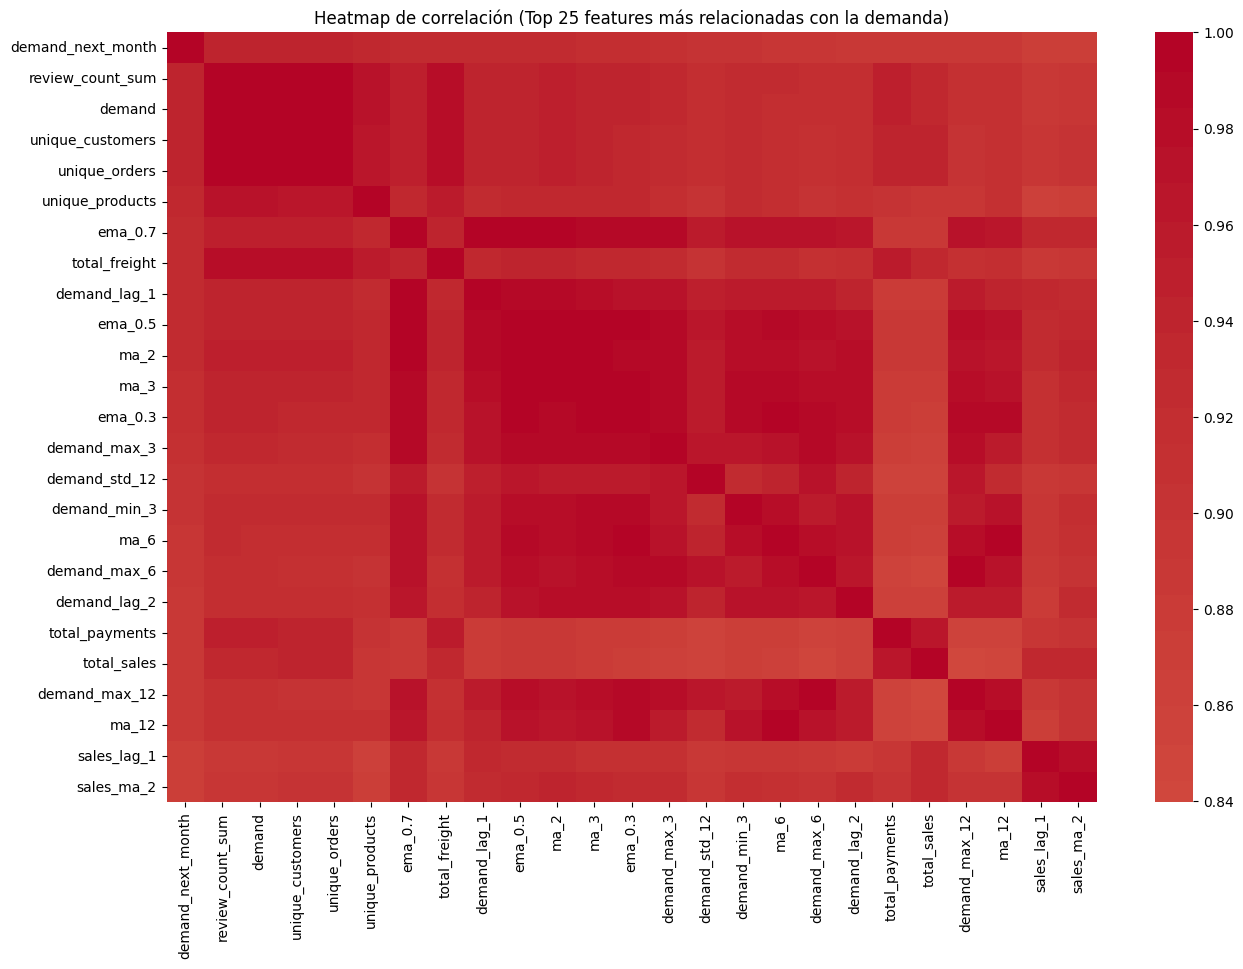

In [70]:
# Heatmap de correlación solo para las 25 más correlacionadas con la target
top_corr_cols = corr_target.head(25).index.tolist()
plt.figure(figsize=(15,10))
sns.heatmap(num_df[top_corr_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title("Heatmap de correlación (Top 25 features más relacionadas con la demanda)")
plt.show()



In [71]:
# X_all: todas las numéricas excepto la target
X_all = num_df.drop(columns=['demand_next_month'])
y_all = num_df['demand_next_month']

corr_matrix = X_all.corr().abs()
corr_matrix.shape


(170, 170)

In [72]:
# Tomamos solo la parte superior de la matriz para no duplicar pares
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Lista de columnas a eliminar (tienen correlación muy alta con alguna otra)
to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]

print("Número de features súper-correlacionadas a eliminar:", len(to_drop))
to_drop[:30]


Número de features súper-correlacionadas a eliminar: 71


['unique_products',
 'unique_orders',
 'unique_customers',
 'unique_sellers',
 'total_sales',
 'total_freight',
 'total_payments',
 'payment_avg_mean',
 'review_count_sum',
 'pct_boleto_mean',
 'quarter',
 'demand_lag_1',
 'sales_lag_1',
 'demand_lag_2',
 'sales_lag_2',
 'demand_lag_3',
 'sales_lag_3',
 'sales_lag_6',
 'sales_lag_12',
 'ma_2',
 'sales_ma_2',
 'price_ma_2',
 'review_ma_2',
 'ma_3',
 'sales_ma_3',
 'price_ma_3',
 'review_ma_3',
 'ma_6',
 'sales_ma_6',
 'price_ma_6']

In [73]:
X_reduced = X_all.drop(columns=to_drop)
print("Shape X_all:", X_all.shape)
print("Shape X_reduced:", X_reduced.shape)


Shape X_all: (1195, 170)
Shape X_reduced: (1195, 99)


Features disponibles para PCA: 170


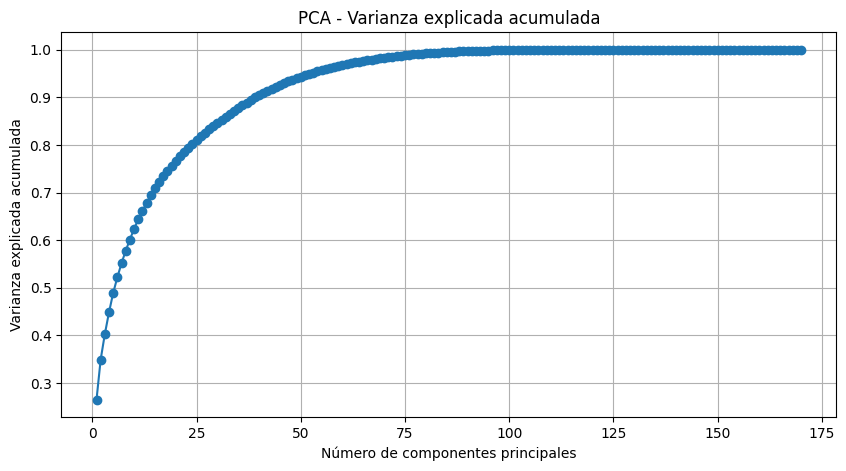

In [13]:
# PCA exploratorio (no para el modelo final)
# X para PCA = todas las numéricas excepto la target
X_all = num_df.drop(columns=['demand_next_month'])
y_all = num_df['demand_next_month']

print("Features disponibles para PCA:", X_all.shape[1])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

pca = PCA()
pca.fit(X_scaled)

var_exp_acum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10,5))
plt.plot(range(1, len(var_exp_acum)+1), var_exp_acum, marker='o')
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza explicada acumulada")
plt.grid(True)
plt.show()


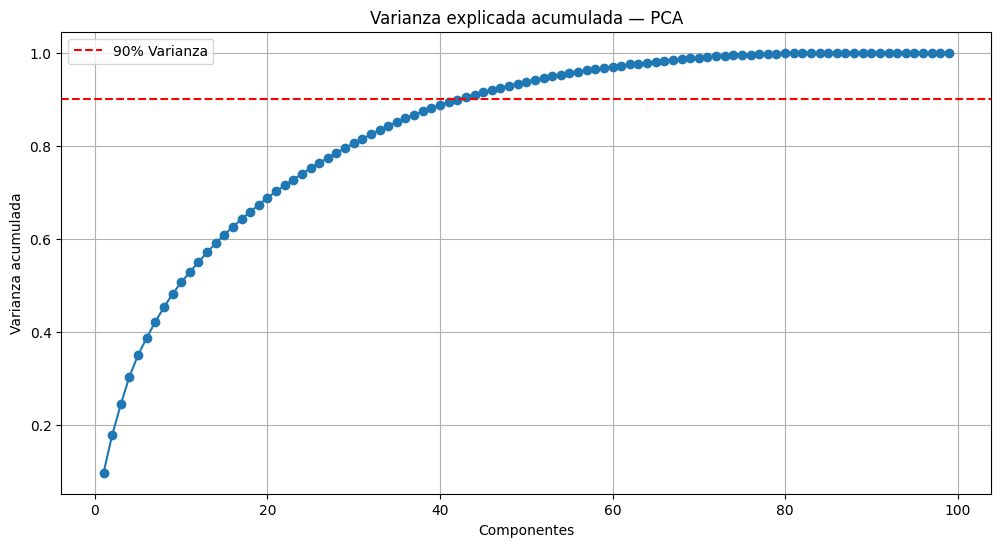

In [74]:
# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)
pca = PCA()
pca.fit(X_scaled)

# Varianza explicada acumulada
varianza_acum = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(12,6))
plt.plot(range(1, len(varianza_acum)+1), varianza_acum, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% Varianza')
plt.title("Varianza explicada acumulada — PCA")
plt.xlabel("Componentes")
plt.ylabel("Varianza acumulada")
plt.legend()
plt.grid(True)
plt.show()


In [75]:
# Eliminar features súper correlacionadas (> 0.90
corr_matrix = X_all.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

print("Features altamente correlacionadas a eliminar (>", 0.90, "):", len(to_drop))
to_drop[:20]


Features altamente correlacionadas a eliminar (> 0.9 ): 71


['unique_products',
 'unique_orders',
 'unique_customers',
 'unique_sellers',
 'total_sales',
 'total_freight',
 'total_payments',
 'payment_avg_mean',
 'review_count_sum',
 'pct_boleto_mean',
 'quarter',
 'demand_lag_1',
 'sales_lag_1',
 'demand_lag_2',
 'sales_lag_2',
 'demand_lag_3',
 'sales_lag_3',
 'sales_lag_6',
 'sales_lag_12',
 'ma_2']

In [76]:
corr_target = X_all.join(y_all).corr()['demand_next_month'] \
                   .abs().sort_values(ascending=False).head(30)

corr_target


,demand_next_month
demand_next_month,1.000000
review_count_sum,0.942555
demand,0.942333
unique_customers,0.941848
unique_orders,0.941848
unique_products,0.935082
ema_0.7,0.926291
total_freight,0.926014
demand_lag_1,0.924339
ema_0.5,0.922579


In [77]:
X_reduced = X_all.drop(columns=to_drop)
print("Shape X_reduced:", X_reduced.shape)


Shape X_reduced: (1195, 99)


In [78]:
# SelectKBest para quedarnos con las mejores features
#k no puede ser mayor al número de columnas
k = min(50, X_reduced.shape[1])

selector = SelectKBest(score_func=f_regression, k=k)
selector.fit(X_reduced, y_all)

selected_features = X_reduced.columns[selector.get_support()]
print("Número de features seleccionadas:", len(selected_features))
selected_features[:30]


Número de features seleccionadas: 50


Index(['demand', 'avg_price', 'price_min', 'price_max', 'avg_freight',
       'avg_payment', 'delivery_time_days_std', 'avg_delivery_delay', 'year',
       'is_december', 'price_lag_1', 'review_lag_1', 'delivery_lag_1',
       'review_lag_2', 'delivery_lag_2', 'review_lag_3', 'delivery_lag_3',
       'demand_lag_6', 'review_lag_6', 'delivery_lag_6', 'demand_lag_12',
       'price_lag_12', 'review_lag_12', 'delivery_lag_12', 'demand_std_3',
       'price_std_3', 'price_std_6', 'demand_growth_1m', 'demand_growth_12m',
       'sales_growth_1m'],
      dtype='object')

In [79]:
X_final = X_reduced[selected_features].copy()
print("Shape X_final:", X_final.shape)


Shape X_final: (1195, 50)


In [80]:
TARGET = "demand_next_month"

drop_cols = ["order_month", "product_category_name", "date"]

df_model = df.drop(columns=drop_cols)

df_model = df_model.dropna(subset=[TARGET])

X_all = df_model.drop(columns=[TARGET])
y_all = df_model[TARGET]

print(X_all.shape, y_all.shape)

FEATURE_SET = [
    # Demanda histórica y lags
    'demand',
    'demand_lag_1',
    'demand_lag_2',
    'demand_lag_3',

    # Moving averages
    'ma_2',
    'ma_3',
    'ma_6',
    'ma_12',

    # EMAs
    'ema_0.3',
    'ema_0.5',
    'ema_0.7',

    # Estadísticos de demanda
    'demand_max_3',
    'demand_min_3',
    'demand_max_6',
    'demand_max_12',
    'demand_std_12',

    # Acumulado anual
    'cumulative_demand_year',

    # Volúmenes de negocio
    'unique_orders',
    'unique_customers',
    'unique_products',
    'unique_sellers',
    'total_sales',
    'total_payments',
    'total_freight',

    # Categoría
    'category_avg_demand',

    # Estacionalidad / calendario
    'month_num',
    'month_sin',
    'month_cos',
    'quarter_sin',
    'quarter_cos',
    'is_holiday_season',
    'is_beginning_year'
]

existing_features = [f for f in FEATURE_SET if f in num_df.columns]
missing_features  = [f for f in FEATURE_SET if f not in num_df.columns]

print("Features usadas (existen en el dataset):", len(existing_features))
print(existing_features)

if missing_features:
    print("\n⚠️ Features NO encontradas (se ignoran):")
    print(missing_features)

X = num_df[existing_features].copy()
y = num_df['demand_next_month'].copy()

print("\nShape X:", X.shape)
print("Shape y:", y.shape)


(1195, 171) (1195,)
Features usadas (existen en el dataset): 32
['demand', 'demand_lag_1', 'demand_lag_2', 'demand_lag_3', 'ma_2', 'ma_3', 'ma_6', 'ma_12', 'ema_0.3', 'ema_0.5', 'ema_0.7', 'demand_max_3', 'demand_min_3', 'demand_max_6', 'demand_max_12', 'demand_std_12', 'cumulative_demand_year', 'unique_orders', 'unique_customers', 'unique_products', 'unique_sellers', 'total_sales', 'total_payments', 'total_freight', 'category_avg_demand', 'month_num', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos', 'is_holiday_season', 'is_beginning_year']

Shape X: (1195, 32)
Shape y: (1195,)


In [81]:
if 'order_month' not in df.columns:
    raise ValueError("La columna 'order_month' no existe en df. No se puede hacer split temporal.")

periods = sorted(df['order_month'].dropna().unique().tolist())
n_periods = len(periods)

print("Períodos totales:", n_periods)
print("Períodos:", periods)

# Test final = último período
test_period = periods[-1]

# Backtest = hasta 3 meses previos al último
n_back = min(3, max(1, n_periods - 1))
backtest_periods = periods[-(n_back+1):-1] if n_periods > 2 else []

print("\nPeríodo TEST FINAL:", test_period)
print("Períodos BACKTEST:", backtest_periods)

train_mask = ~df['order_month'].isin(backtest_periods + [test_period])
back_mask  = df['order_month'].isin(backtest_periods)
test_mask  = df['order_month'] == test_period

X_train, y_train = X[train_mask], y[train_mask]
X_back,  y_back  = X[back_mask],  y[back_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("\nShapes:")
print("Train:", X_train.shape, y_train.shape)
print("Backtest:", X_back.shape, y_back.shape)
print("Test:", X_test.shape, y_test.shape)



Períodos totales: 21
Períodos: [Timestamp('2016-10-01 00:00:00'), Timestamp('2016-12-01 00:00:00'), Timestamp('2017-01-01 00:00:00'), Timestamp('2017-02-01 00:00:00'), Timestamp('2017-03-01 00:00:00'), Timestamp('2017-04-01 00:00:00'), Timestamp('2017-05-01 00:00:00'), Timestamp('2017-06-01 00:00:00'), Timestamp('2017-07-01 00:00:00'), Timestamp('2017-08-01 00:00:00'), Timestamp('2017-09-01 00:00:00'), Timestamp('2017-10-01 00:00:00'), Timestamp('2017-11-01 00:00:00'), Timestamp('2017-12-01 00:00:00'), Timestamp('2018-01-01 00:00:00'), Timestamp('2018-02-01 00:00:00'), Timestamp('2018-03-01 00:00:00'), Timestamp('2018-04-01 00:00:00'), Timestamp('2018-05-01 00:00:00'), Timestamp('2018-06-01 00:00:00'), Timestamp('2018-07-01 00:00:00')]

Período TEST FINAL: 2018-07-01 00:00:00
Períodos BACKTEST: [Timestamp('2018-04-01 00:00:00'), Timestamp('2018-05-01 00:00:00'), Timestamp('2018-06-01 00:00:00')]

Shapes:
Train: (937, 32) (937,)
Backtest: (194, 32) (194,)
Test: (64, 32) (64,)


In [82]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluar_modelo(nombre, y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape_val = mape(y_true, y_pred)

    print(f"{nombre:<20}  MAE: {mae:8.2f}  RMSE: {rmse:8.2f}  MAPE: {mape_val:8.2f}%  R²: {r2:6.3f}")
    return {"mae": mae, "rmse": rmse, "mape": mape_val, "r2": r2}



In [83]:
print("=== BASELINE NAIVE ===")

if len(y_train) == 0:
    raise ValueError("No hay datos de entrenamiento para el baseline Naive.")

last_value = y_train.iloc[-1]

print("Backtest:")
y_pred_naive_back = np.full_like(y_back, fill_value=last_value, dtype=float)
metrics_naive_back = evaluar_modelo("NAIVE_LAST_VALUE", y_back, y_pred_naive_back)

print("\nTest final:")
y_pred_naive_test = np.full_like(y_test, fill_value=last_value, dtype=float)
metrics_naive_test = evaluar_modelo("NAIVE_LAST_VALUE", y_test, y_pred_naive_test)



=== BASELINE NAIVE ===
Backtest:
NAIVE_LAST_VALUE      MAE:   352.80  RMSE:   369.27  MAPE:  4430.18%  R²: -3.544

Test final:
NAIVE_LAST_VALUE      MAE:   348.70  RMSE:   367.47  MAPE:  4953.29%  R²: -3.488


In [84]:
lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# BACKTEST
print("=== BACKTEST MODELOS BASE ===")
y_pred_lr_back = lr.predict(X_back)
y_pred_rf_back = rf.predict(X_back)

metrics_lr_back = evaluar_modelo("LINEAR_REGRESSION", y_back, y_pred_lr_back)
metrics_rf_back = evaluar_modelo("RANDOM_FOREST",   y_back, y_pred_rf_back)

# TEST FINAL
print("\n=== TEST FINAL MODELOS BASE ===")
y_pred_lr_test = lr.predict(X_test)
y_pred_rf_test = rf.predict(X_test)

metrics_lr_test = evaluar_modelo("LINEAR_REGRESSION", y_test, y_pred_lr_test)
metrics_rf_test = evaluar_modelo("RANDOM_FOREST",   y_test, y_pred_rf_test)


=== BACKTEST MODELOS BASE ===
LINEAR_REGRESSION     MAE:    34.27  RMSE:    63.76  MAPE:    74.56%  R²:  0.865
RANDOM_FOREST         MAE:    34.66  RMSE:    69.93  MAPE:    56.47%  R²:  0.837

=== TEST FINAL MODELOS BASE ===
LINEAR_REGRESSION     MAE:    27.21  RMSE:    47.95  MAPE:    56.02%  R²:  0.924
RANDOM_FOREST         MAE:    31.11  RMSE:    60.63  MAPE:    60.03%  R²:  0.878


In [85]:
tscv = TimeSeriesSplit(n_splits=3)

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [6, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print(" Buscando mejores hiperparámetros para RandomForest...")
random_search.fit(X_train, y_train)

print("\n Mejores hiperparámetros encontrados:")
print(random_search.best_params_)
print("Mejor score (MAE CV negativo):", random_search.best_score_)

best_rf = random_search.best_estimator_


 Buscando mejores hiperparámetros para RandomForest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Mejores hiperparámetros encontrados:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': None}
Mejor score (MAE CV negativo): -29.469013148653477


In [86]:
print("=== RANDOM FOREST TUNADO ===")

# BACKTEST
y_pred_best_rf_back = best_rf.predict(X_back)
metrics_best_rf_back = evaluar_modelo("RF_TUNED_BACK", y_back, y_pred_best_rf_back)

# TEST FINAL
y_pred_best_rf_test = best_rf.predict(X_test)
metrics_best_rf_test = evaluar_modelo("RF_TUNED_TEST", y_test, y_pred_best_rf_test)


=== RANDOM FOREST TUNADO ===
RF_TUNED_BACK         MAE:    32.25  RMSE:    63.71  MAPE:    55.25%  R²:  0.865
RF_TUNED_TEST         MAE:    28.78  RMSE:    56.15  MAPE:    60.41%  R²:  0.895


In [87]:
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    print("⏳ Entrenando XGBoost...")
    xgb_model.fit(X_train, y_train)

    # BACKTEST
    print("\n=== XGBOOST BACKTEST ===")
    y_pred_xgb_back = xgb_model.predict(X_back)
    metrics_xgb_back = evaluar_modelo("XGBOOST_BACK", y_back, y_pred_xgb_back)

    # TEST FINAL
    print("\n=== XGBOOST TEST FINAL ===")
    y_pred_xgb_test = xgb_model.predict(X_test)
    metrics_xgb_test = evaluar_modelo("XGBOOST_TEST", y_test, y_pred_xgb_test)
else:
    print(" XGBoost no está disponible. Esta sección se omite.")


⏳ Entrenando XGBoost...

=== XGBOOST BACKTEST ===
XGBOOST_BACK          MAE:    34.15  RMSE:    65.47  MAPE:    59.05%  R²:  0.857

=== XGBOOST TEST FINAL ===
XGBOOST_TEST          MAE:    31.44  RMSE:    62.54  MAPE:    65.27%  R²:  0.870


In [88]:
def cv_mae(modelo, X, y, cv):
    scores = cross_val_score(
        modelo,
        X, y,
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_jobs=-1
    )
    return -scores.mean(), -scores.std()

models_cv = {
    "LinearRegression": lr,
    "RandomForest base": rf,
    "RandomForest tunado": best_rf
}

if XGB_AVAILABLE:
    models_cv["XGBoost"] = xgb_model

print("=== VALIDACIÓN CRUZADA (TimeSeriesSplit, MAE) ===")
for nombre, modelo in models_cv.items():
    mae_mean, mae_std = cv_mae(modelo, X_train, y_train, tscv)
    print(f"{nombre:<20}  MAE CV: {mae_mean:8.2f} ± {mae_std:6.2f}")


=== VALIDACIÓN CRUZADA (TimeSeriesSplit, MAE) ===
LinearRegression      MAE CV:    79.41 ± -18.82
RandomForest base     MAE CV:    30.52 ±  -7.50
RandomForest tunado   MAE CV:    29.47 ±  -5.43
XGBoost               MAE CV:    29.48 ±  -4.94


In [89]:
importancias = pd.Series(best_rf.feature_importances_, index=X_train.columns) \
               .sort_values(ascending=False)

print("Top 20 features más importantes (RF Tunado):")
importancias.head(20)


Top 20 features más importantes (RF Tunado):


,0
demand,0.335220
unique_orders,0.149979
unique_customers,0.110699
demand_lag_1,0.074904
demand_std_12,0.041040
ema_0.3,0.040957
demand_min_3,0.030458
unique_products,0.028958
total_freight,0.026998
ema_0.7,0.024576


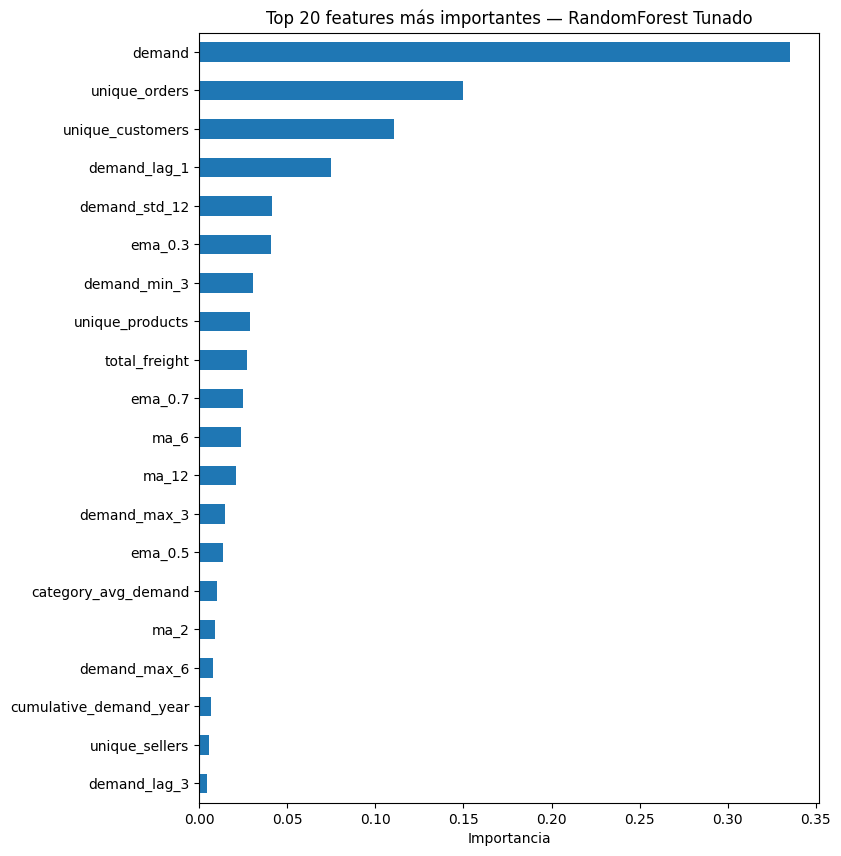

In [90]:
plt.figure(figsize=(8,10))
importancias.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 features más importantes — RandomForest Tunado")
plt.xlabel("Importancia")
plt.show()


In [91]:
df_eval = df.copy()
df_eval['y_true'] = y.values
df_eval['y_pred_rf'] = np.nan

df_eval.loc[back_mask, 'y_pred_rf'] = y_pred_best_rf_back
df_eval.loc[test_mask, 'y_pred_rf'] = y_pred_best_rf_test

def mape_group(g):
    return mape(g['y_true'], g['y_pred_rf'])

# MAPE por categoría
if 'product_category_name' in df_eval.columns:
    mape_cat = df_eval[df_eval['y_pred_rf'].notna()] \
        .groupby('product_category_name') \
        .apply(mape_group) \
        .sort_values()
    print("Top 10 categorías con menor MAPE (RF Tunado):")
    print(mape_cat.head(10))
else:
    print("No existe 'product_category_name' en df.")


Top 10 categorías con menor MAPE (RF Tunado):
product_category_name
cama_mesa_banho            8.969308
utilidades_domesticas      9.855603
beleza_saude              12.772731
moveis_quarto             13.577284
perfumaria                14.577635
bebes                     16.088698
climatizacao              16.720648
eletrodomesticos_2        16.781353
papelaria                 18.778637
fashion_roupa_feminina    19.416714
dtype: float64


/tmp/ipython-input-2370588877.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mape_group) \


In [92]:
# MAPE por mes (month_year si existe, si no order_month)
group_col = 'month_year' if 'month_year' in df_eval.columns else 'order_month'

mape_mes = df_eval[df_eval['y_pred_rf'].notna()] \
    .groupby(group_col) \
    .apply(mape_group) \
    .sort_index()

print("MAPE por mes (RF Tunado):")
print(mape_mes)


MAPE por mes (RF Tunado):
month_year
2018-04    55.885126
2018-05    52.607869
2018-06    57.321798
2018-07    60.408594
dtype: float64


/tmp/ipython-input-453424615.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mape_group) \


In [94]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f"modelo_demanda_rf_final_{timestamp}.pkl"

joblib.dump(best_rf, model_filename)
print(f" Modelo final guardado como: {model_filename}")


 Modelo final guardado como: modelo_demanda_rf_final_20251127_001357.pkl
